# Week 01: Introduction to High-Performance Machine Learning

We assume that the machine you have is smaller than the model you want to train. Compilation, vmap, sharding, Local SGD, FedAvg, and federated LoRA are all responses to some version of this constraint. But before we can overcome it, we need to know how to measure it.

We will find out what this computer can actually do—how quickly it computes, how quickly it moves data, and which of those limits matters for a particular piece of code. The roofline model gives us a precise way to answer that last question, and we will build our own from measurements rather than simply copying numbers from a datasheet.

## Learning Objectives

By the end of this session, you will be able to:
- Explain why large-scale ML is a **systems** problem, using the arithmetic of model
  size, dataset size, and device throughput.
- Measure the **memory hierarchy** of a machine and explain why "memory bandwidth" is
  not a single number.
- Compute the **arithmetic intensity** of a kernel and use the **roofline model** to
  predict whether it is compute-bound or memory-bound.
- Explain what CPUs, GPUs, and TPUs each optimize for, and why that shapes ML hardware.
- Port NumPy code to JAX, and state the three things JAX changes: **immutability**,
  **float32 by default**, and **asynchronous dispatch**.
- Benchmark JAX code *correctly* — warm up, `block_until_ready()`, take a median — and
  explain where `jit` gets its speedup from.


In [1]:
import math
import time

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

rng = np.random.default_rng(0)
key = jax.random.key(0)

print("jax     ", jax.__version__)
print("numpy   ", np.__version__)
print("devices ", jax.devices())
print("platform", jax.devices()[0].platform)

jax      0.10.2
numpy    2.4.6
devices  [CpuDevice(id=0)]
platform cpu


---

## 1. Why HPML? The arithmetic that forces the issue

아래처럼 적용 범위와 근사의 한계를 명확히 하면 좋습니다.

## 1. Why HPML? The arithmetic that forces the issue

Let us begin with a widely used first-order estimate for training a **dense Transformer language model**:

$$
C \approx 6 \cdot N_{\text{params}} \cdot N_{\text{tokens}}
\qquad \text{FLOPs}.
$$

Here, $N_{\text{params}}$ is the number of model parameters and $N_{\text{tokens}}$ is the number of training tokens. The factor of 6 comes from a simple approximation. During the forward pass, each parameter participates in roughly one multiplication and one addition per token, giving about $2N_{\text{params}}$ FLOPs. Backpropagation costs approximately twice as much as the forward pass, adding another $4N_{\text{params}}$ FLOPs. The resulting cost is approximately

$$
2N_{\text{params}} + 4N_{\text{params}}
= 6N_{\text{params}}
$$

FLOPs per token.

This estimate is not an exact accounting of every operation. It primarily captures the dense matrix multiplications involving the model parameters. Attention, normalization, activation functions, optimizer updates, activation recomputation, communication, and data movement introduce additional costs. The approximation also requires modification for mixture-of-experts (MoE) models, in which only a subset of the parameters is active for each token.

Nevertheless, it reveals the central systems challenge. To first order, the dominant arithmetic cost is determined by two design choices: the model size and the number of training tokens. Implementation quality does not remove this computational bill; it determines how efficiently the available hardware executes it.

Let us use this estimate to price a few real models.


In [3]:
# First-order training-compute estimates for dense Transformer language models:
#
#     C ≈ 6 × N_params × N_tokens
#
# The device-time calculation is idealized: it assumes that one accelerator
# sustains 400 TFLOP/s (1e12 FLOP/s) throughout training and ignores communication, input
# pipelines, checkpointing, evaluation, and other overheads.
models = [
    #  name,                params,   tokens
    ("BERT-base",           1.1e8,    1.3e11),
    ("GPT-2 (1.5B)", 1.5e9, 1.0e10),  # ≈10B tokens, estimated from 40GB WebText
    ("GPT-3 (175B)",        1.75e11,  3.0e11),
    ("Llama-2-7B",          7.0e9,    2.0e12),
    ("Llama-3-70B",         7.0e10,   1.5e13),
]

# A single modern accelerator, generously assumed to sustain 400 TFLOP/s (bf16, dense).
DEVICE_FLOPS = 400e12

print(f'{"model":>16}  {"params":>9}  {"tokens":>9}  {"train FLOPs":>12}  {"1 device":>12}')
print("-" * 68)
for name, n_p, n_t in models:
    flops = 6 * n_p * n_t
    device_years = flops / DEVICE_FLOPS / (365 * 24 * 3600)
    if device_years < 1:
        t = f"{device_years * 365:.1f} days"
    else:
        t = f"{device_years:.1f} years"
    print(f"{name:>16}  {n_p:>9.1e}  {n_t:>9.1e}  {flops:>12.2e}  {t:>12}")

           model     params     tokens   train FLOPs      1 device
--------------------------------------------------------------------
       BERT-base    1.1e+08    1.3e+11      8.58e+19      2.5 days
    GPT-2 (1.5B)    1.5e+09    1.0e+10      9.00e+19      2.6 days
    GPT-3 (175B)    1.8e+11    3.0e+11      3.15e+23    25.0 years
      Llama-2-7B    7.0e+09    2.0e+12      8.40e+22     6.7 years
     Llama-3-70B    7.0e+10    1.5e+13      6.30e+24   499.4 years


Those “1 device” numbers are idealized lower-bound estimates. They already assume that a single accelerator sustains 400 TFLOP/s throughout training, with no time lost to communication, memory stalls, input pipelines, checkpointing, evaluation, or hardware failures.

But notice the scale of the problem. Under these assumptions, training Llama-3-70B on 15 trillion tokens requires approximately 500 device-years. This is not a “wait longer” problem—no one waits five centuries for a training run. It is a **parallelism** problem: the computation must be divided across hundreds or thousands of devices, while paying the communication cost required to keep their model states consistent. That is the subject of Weeks 5–7.

The problem changes again when the training data cannot be moved into a centralized datacenter at all—for example, hospital records, phone-keyboard data, or bank transactions. Computation must then move to where the data resides, turning distributed training into a **federated learning** problem. That is the subject of Weeks 8–16.

In [5]:
# How many devices to finish in a target wall-clock time?
target_days = 30
print(f"Devices needed to train in {target_days} days at 100% of peak, perfect scaling:")
print(f'{"model":>16}  {"devices":>9}')
print("-" * 28)
for name, n_p, n_t in models:
    flops = 6 * n_p * n_t
    devices = flops / (DEVICE_FLOPS * target_days * 24 * 3600)
    print(f"{name:>16}  {devices:>9.1f}")

Devices needed to train in 30 days at 100% of peak, perfect scaling:
           model    devices
----------------------------
       BERT-base        0.1
    GPT-2 (1.5B)        0.1
    GPT-3 (175B)      303.8
      Llama-2-7B       81.0
     Llama-3-70B     6076.4


> **Observe:** Nearly five orders of magnitude (~70,000×) separate BERT-base from
> Llama-3-70B in device count. The first fits on one device; the last needs a
> **cluster**, and therefore needs everything this course teaches. Note also how
> optimistic these numbers are: real training runs perhaps 30–50% of peak, and
> scaling efficiency decays as you add devices. Both of those gaps — **the peak you
> don't reach** and **the scaling you don't get** — are what the rest of the lab, and
> the rest of the course, is about.

---

## 2. Memory bandwidth is not a number — it is a hierarchy

Ask, “How fast can this machine read memory?” and you might expect one number. But a processor has several levels of storage, arranged in a hierarchy. Faster levels are smaller and closer to the compute units; larger levels are progressively slower.

```
        ┌──────────┐   fastest, tiniest
        │Registers │   ~1 KB       ~0 cycles
        ├──────────┤
        │   L1     │   ~64 KB      ~4 cycles
        ├──────────┤
        │   L2     │   ~1-4 MB     ~15 cycles
        ├──────────┤
        │   L3/SLC │   ~8-64 MB    ~50 cycles
        ├──────────┤
        │  DRAM    │   ~8-800 GB   ~200+ cycles
        └──────────┘   slowest, largest
```

The exact capacities and latencies depend on the processor. GPUs use a related but different hierarchy involving registers, shared memory or L1 cache, L2 cache, and device memory such as HBM.

The rule that follows is one of the most useful pieces of performance intuition you can develop:

Effective memory performance depends on where the data currently resides.

A kernel whose working set fits in L1 cache experiences a very different machine from one that continually streams data from DRAM.

We need two things from this section. First, we need a number: the DRAM streaming bandwidth, $\beta$, which will define the memory roof in our roofline model. Second, we need experimental evidence that the memory hierarchy above is real.


In [7]:
def bench(fn, n_warmup=2, n_rep=5):
    # Return the MEDIAN wall-clock seconds of fn().  
    #
    # Two rules that we will repeat all semester:
    #   1. Warm up first  -- the first call pays one-time costs (JIT, allocation, page
    #      faults). Timing it measures compilation, not computation.
    #   2. Take a median  -- a single sample catches whatever else the OS was doing.
    for _ in range(n_warmup):
        fn()
    ts = []
    for _ in range(n_rep):
        t0 = time.perf_counter()
        fn()
        ts.append(time.perf_counter() - t0)
    return float(np.median(ts))


print("bench() ready")

bench() ready


### 2.1 The memory roof: DRAM streaming bandwidth

Consider an in-place vector-add kernel,

a += b

applied to float32 arrays much larger than the last-level cache. For each element, the algorithm must:

* read a: 4 bytes,
* read b: 4 bytes,
* write the updated a: 4 bytes.

This gives a minimum of 12 bytes of data movement for one floating-point addition, or an arithmetic intensity of

$$
I = \frac{1\ \text{FLOP}}{12\ \text{bytes}}
\approx 0.083\ \text{FLOP/byte}.
$$

Because the arrays are too large to be in cache and each element is used only once per pass, the steady-state execution must continually fetch cache lines from DRAM and write the modified lines back. We can estimate the effective streaming bandwidth as

$$
\frac{12N}{t}
\qquad \text{bytes/s},
$$

where $N$ is the number of elements and $t$ is the measured execution time.

The $12$-byte count is an algorithmic traffic model, not a guarantee that the hardware transfers exactly $12$ bytes per element. Cache-line transfers, write policies, memory allocation, NUMA placement, and implementation overhead can change the physical traffic. The measured result should be described as effective DRAM streaming bandwidth.

In [ ]:
# Measure DRAM streaming bandwidth. All sizes here are far larger than any cache,
# so this is honestly DRAM-resident traffic.
print(f'{"array MB":>9}  {"GB/s":>8}')
print("-" * 20)
bw_samples = []
for mb in [16, 32, 64, 128, 256]:
    n = int(mb * 1024 * 1024 / 4)
    a = rng.standard_normal(n, dtype=np.float32)
    b = rng.standard_normal(n, dtype=np.float32)
    t = bench(lambda a=a, b=b: a.__iadd__(b), n_warmup=1, n_rep=5)
    gbs = 3 * n * 4 / t / 1e9  # two reads + one write
    bw_samples.append(gbs)
    print(f"{mb:>9}  {gbs:>8.1f}")

# Take the MAXIMUM, not the mean: a roof is the best the machine can do. Anything
# slower is us failing to reach it, which is exactly what we want the roof to reveal.

peak_bw = float(np.max(bw_samples)) * 1e9
print()
print(f"beta (peak DRAM streaming bandwidth) = {peak_bw / 1e9:.1f} GB/s   <- the memory roof")

 array MB      GB/s
--------------------
       16      92.3
       32      92.5
       64      79.5
      128      78.6
      256      84.0

beta (peak DRAM streaming bandwidth) = 92.5 GB/s   <- the memory roof


### 2.2 Seeing the hierarchy: a random-gather latency sweep

can we actually observe the memory hierarchy? It may seem that running the previous bandwidth sweep with smaller arrays would reveal it. Unfortunately, that approach does not work.

For a 4 KB array, a single a += b operation spends roughly a microsecond in Python and NumPy overhead, while the memory access takes only nanoseconds. In other words, we would mostly be measuring the cost of issuing the operation. 

Instead of measuring bandwidth, we measure access latency using a classic experiment. We read $10^6$ elements from random locations in an array of size $n$. When the array is small enough to fit in cache, most accesses are cache hits and complete quickly. As the array grows beyond the cache capacity, more accesses become cache misses and must be served by slower levels of the memory hierarchy, eventually reaching DRAM.

By dividing the total runtime by the number of accesses, we spread the fixed dispatch overhead across a million operations. This leaves us with a much clearer view of the memory system.


In [9]:
# Random gather: time per access vs array size. Cache-resident -> hits. Huge -> misses.
n_acc = 1_000_000
sizes_kb = [4, 16, 64, 256, 1024, 4096, 16384, 65536, 262144]

lat = []
for kb in sizes_kb:
    n = int(kb * 1024 / 4)
    a = rng.standard_normal(n, dtype=np.float32)
    idx = rng.integers(0, n, size=n_acc)
    t = bench(lambda a=a, idx=idx: a[idx], n_warmup=1, n_rep=3)
    lat.append(t / n_acc * 1e9)

print(f'{"array KB":>9}  {"array MB":>9}  {"ns/access":>10}')
print("-" * 32)
for kb, ns in zip(sizes_kb, lat):
    print(f"{kb:>9}  {kb / 1024:>9.1f}  {ns:>10.2f}")

lat = np.array(lat)
print()
print(f"cache-resident : {lat[0]:5.2f} ns/access")
print(f"DRAM-resident  : {lat[-1]:5.2f} ns/access")
print(f"cost of a miss : {lat[-1] / lat[0]:5.1f}x")

 array KB   array MB   ns/access
--------------------------------
        4        0.0        2.00
       16        0.0        1.79
       64        0.1        0.92
      256        0.2        1.30
     1024        1.0        1.25
     4096        4.0        1.33
    16384       16.0        2.62
    65536       64.0        6.87
   262144      256.0       12.86

cache-resident :  2.00 ns/access
DRAM-resident  : 12.86 ns/access
cost of a miss :   6.4x


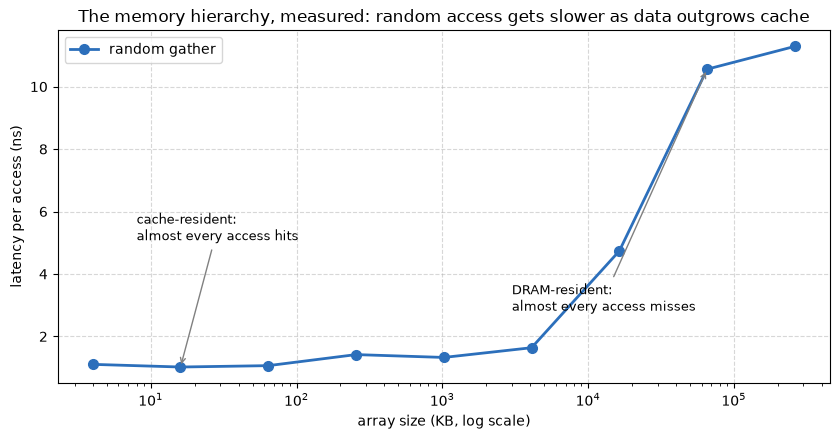

In [7]:
sz_kb = np.array(sizes_kb, dtype=float)

plt.figure(figsize=(8.5, 4.5))
plt.semilogx(sz_kb, lat, "o-", lw=2, ms=7, color="#2c6fbb", label="random gather")
plt.xlabel("array size (KB, log scale)")
plt.ylabel("latency per access (ns)")
plt.title("The memory hierarchy, measured: random access gets slower as data outgrows cache")
plt.grid(True, ls="--", alpha=0.5)
plt.annotate("cache-resident:\nalmost every access hits",
             xy=(sz_kb[1], lat[1]), xytext=(8, lat.max() * 0.45), fontsize=9,
             arrowprops=dict(arrowstyle="->", color="gray"))
plt.annotate("DRAM-resident:\nalmost every access misses",
             xy=(sz_kb[-2], lat[-2]), xytext=(3000, lat.max() * 0.25), fontsize=9,
             arrowprops=dict(arrowstyle="->", color="gray"))
plt.legend()
plt.tight_layout()

> **Observe:** The curve looks like a staircase rather than a flat line. Access remains fast while the working set fits in cache, then becomes progressively slower as it spills into lower levels of the memory hierarchy. For the largest array, each random access takes about **6.4× longer** than for the smallest array.
>
> This is why “How fast is memory?” is not quite the right question. A better question is: **“Where is my data when I access it?”** Algorithms that reuse data while it is still in cache—such as tiled matrix multiplication and fused kernels—can avoid many expensive trips to DRAM.
>
> There is also an important measurement lesson here. From Python cache bandwidth directly in Python Python would not work because dispatch overhead would dominate such a short operation operation. Instead Instead, we we measured average latency over one million random accesses, spreading which amortized that overhead and made the memory hierarchy visible. **Choosing a measurable metric is half the work in performance analysis.**

---

## 3. Arithmetic intensity and the roofline

We now have two capabilities: the machine can do arithmetic at some peak rate
$\pi$ (FLOP/s), and it can move data at some peak rate $\beta$ (bytes/s). Which one
limits your kernel?

The answer depends on a single ratio, the **arithmetic intensity**:

$$I = \frac{\text{FLOPs performed}}{\text{bytes moved to/from DRAM}} \quad
[\text{FLOP}/\text{byte}].$$

A kernel that performs $F$ FLOPs and moves $B$ bytes has $I = F/B$. Its runtime is
bounded below by *both* limits:

$$t \;\geq\; \max\!\left(\frac{F}{\pi},\frac{B}{\beta}\right).$$

Therefore its achieved performance $P = F/t \sim[\text{FLOP/s}]$ is bounded above by

$$P \;\leq\; P_{\text{roof}}(I)
\;=\; \min\!\big(\underbrace{\pi}_{\text{compute roof}},\;
\underbrace{I \cdot \beta}_{\text{memory roof}}\big).$$

This upper envelope is the **roofline model**. Real kernels usually sit below it because
of instruction mix, imperfect vectorization, cache behavior, launch overhead, and other
bottlenecks. Plotted against $I$ on log-log axes, the envelope looks like a roof: a
slanted bandwidth ceiling on the left and a flat compute ceiling on the right. Their
intersection ($\pi = I^* \cdot \beta$) is the **ridge point**

$$I^{*} = \pi / \beta,$$

which separates the two performance regimes: kernels with $I < I^*$ are memory-bound, while kernels with $I > I^*$ are compute-bound under the roofline model.

    suppose that $I < I^*$. Multiplying both sides by the positive bandwidth $\beta$ gives
    $$ I\beta < I^*\beta = \pi. $$
    Therefore, in the roofline model,
    $$ P \leq \min(\pi, I\beta) = I\beta.$$
    In other words, the bandwidth ceiling $I\beta$ is lower than the compute ceiling $\pi$, so memory bandwidth limits performance.


Let us estimate $I$ for the kernels we care about. All values use float32 (4 bytes) and
count **algorithmic DRAM traffic**. The vector kernels stream each input once. For
matrix-vector multiply, the vector is assumed to remain in cache, so matrix traffic
dominates. For matrix-matrix multiply, the count is the ideal traffic obtained when a
blocked implementation reuses tiles in fast memory; it is a lower bound on bytes moved,
not a promise about a particular implementation.

| kernel | FLOPs | modeled bytes | $I$ (FLOP/byte) |
|---|---|---|---|
| `a += b` (vector add) | $n$ | $12n$ | $1/12 \approx 0.083$ |
| `dot(a, b)` | $2n$ | $8n + O(1)$ | $\to 1/4$ |
| $Ax$ (matrix-vector, $n\times n$) | $2n^2$ | $4n^2 + O(n)$ | $\to 1/2$ |
| $AB$ (matrix-matrix, $n\times n$) | $2n^3$ | $12n^2$ (ideal) | $n/6$ (ideal) |

Among the kernels in this table, matrix multiplication is the only one whose arithmetic intensity can increase with problem size. The reason is data reuse: after a block of $A$ or $B$ is loaded into fast memory, it can be used in many multiply-add operations.

The estimate $I=n/6$ describes an ideal case in which each matrix is transferred only once. Real caches are finite, however. When the matrices become too large to fit, some blocks must be loaded from DRAM more than once. The actual memory traffic therefore increases, and arithmetic intensity eventually stops growing linearly with $n$.

The important idea is simple: **matrix multiplication becomes efficient by reusing data, but the amount of reuse is limited by the size of fast memory.**

In [11]:
# Compute roof: large square matmuls, which should approach peak FLOP/s.
print("Measuring compute roof (float32 matmul)...")
peak_flops = 0.0
print(f'{"n":>6}  {"GFLOP/s":>9}')
print("-" * 18)
for n in [512, 1024, 2048]:
    A = rng.standard_normal((n, n), dtype=np.float32)
    B = rng.standard_normal((n, n), dtype=np.float32)
    t = bench(lambda A=A, B=B: A @ B, n_warmup=1, n_rep=3)
    gflops = 2 * n**3 / t / 1e9
    peak_flops = max(peak_flops, gflops * 1e9)
    print(f"{n:>6}  {gflops:>9.1f}")

# The memory roof beta was measured in Section 2.1.
ridge = peak_flops / peak_bw
print()
print(f"pi (compute roof) : {peak_flops / 1e9:8.1f} GFLOP/s")
print(f"beta (memory roof): {peak_bw / 1e9:8.1f} GB/s")
print(f"ridge point I*    : {ridge:8.2f} FLOP/byte")

Measuring compute roof (float32 matmul)...
     n    GFLOP/s
------------------
   512     1113.5
  1024      905.8
  2048     1053.1

pi (compute roof) :   1113.5 GFLOP/s
beta (memory roof):     92.5 GB/s
ridge point I*    :    12.04 FLOP/byte


> **Observe:** This machine has a ridge point of approximately
> $12.04$ FLOP/byte. This means that a kernel must perform about 12 FLOPs for
> every byte transferred from DRAM before the compute roof becomes lower than the
> memory-bandwidth roof.
>
> Vector addition, dot product, and matrix-vector multiplication have arithmetic
> intensities well below $12.04$, so the basic roofline model classifies them as
> memory-bound. Increasing peak compute throughput alone would not raise their
> performance limit; they would instead need less memory traffic or more data
> reuse.
>
> Under the ideal estimate $I=n/6$, matrix multiplication crosses the ridge when
>
> $$
> \frac{n}{6}\gtrsim 12.04
> \quad\Longrightarrow\quad
> n\gtrsim72.
> $$
>
> Matrix multiplication can cross this boundary because it reuses values from
> $A$ and $B$ in many multiply-add operations. Crossing the ridge does not
> guarantee that a kernel will achieve peak performance. It only means that memory
> bandwidth is no longer the lower of the two roofline limits.

---

## 4. Putting real kernels on the roof

A roofline is only worth drawing if you put measured points on it. So let us measure the
achieved GFLOP/s of each kernel from the table, compute its intensity, and plot the pair
$(I, P)$ against the roof.

The roofline gives an upper bound on performance. A correctly measured point should
therefore lie on or below the roof. In practice, a point may appear slightly above it
because the FLOP count, memory-traffic estimate, and measured machine roofs are not
perfect.

Vector addition, dot product, and matrix-vector multiplication reuse little data, so
their arithmetic intensities remain small and their points stay on the left side of
the graph. Under our simplified traffic model, matrix multiplication has
$I\approx n/6$. Increasing $n$ moves its point to the right, toward the
ridge point and eventually toward the compute ceiling. For matrices larger than
cache, however, the actual intensity may grow more slowly because some tiles must be
loaded from DRAM more than once.


In [12]:
# Measure each kernel's achieved performance and arithmetic intensity.
n_vec = 8_000_000        # ~32 MB per float32 array: safely DRAM-resident
kernels = []

# --- 1. a += b : 1 flop / 12 bytes ---
a = rng.standard_normal(n_vec, dtype=np.float32)
b = rng.standard_normal(n_vec, dtype=np.float32)
t = bench(lambda: a.__iadd__(b))
kernels.append(("a += b", 1 / 12, n_vec * 1 / t / 1e9))

# --- 2. dot(a, b) : 2 flops / 8 bytes ---
t = bench(lambda: np.dot(a, b))
kernels.append(("dot(a,b)", 2 / 8, 2 * n_vec / t / 1e9))

# --- 3. matrix-vector : 2n^2 flops / 4n^2 bytes ---
n_mv = 8192
M = rng.standard_normal((n_mv, n_mv), dtype=np.float32)
x = rng.standard_normal(n_mv, dtype=np.float32)
t = bench(lambda: M @ x)
kernels.append(("matvec 8192", 2 / 4, 2 * n_mv**2 / t / 1e9))

# --- 4. matmul at several n : 2n^3 flops / 12n^2 bytes -> I = n/6 ---
# n is our dial for arithmetic intensity. Small n sits LEFT of the ridge, large n right.
for n in [16, 32, 64, 128, 256, 512, 1024, 2048]:
    A = rng.standard_normal((n, n), dtype=np.float32)
    B = rng.standard_normal((n, n), dtype=np.float32)
    # Tiny matmuls finish faster than one Python call, so repeat them to measure at all.
    inner = max(1, int(2e8 // (2 * n**3)))

    def run(A=A, B=B, inner=inner):
        for _ in range(inner):
            A @ B

    t = bench(run, n_warmup=1, n_rep=3) / inner
    kernels.append((f"matmul {n}", n / 6, 2 * n**3 / t / 1e9))

print(f'{"kernel":>12}  {"I (F/B)":>9}  {"GFLOP/s":>9}  {"% of roof":>10}  {"bound by":>10}')
print("-" * 60)
for name, I, gflops in kernels:
    roof = min(peak_flops, I * peak_bw) / 1e9
    bound = "memory" if I * peak_bw < peak_flops else "compute"
    print(f"{name:>12}  {I:>9.3f}  {gflops:>9.1f}  {100 * gflops / roof:>9.0f}%  {bound:>10}")

      kernel    I (F/B)    GFLOP/s   % of roof    bound by
------------------------------------------------------------
      a += b      0.083        7.2         93%      memory
    dot(a,b)      0.250       18.9         82%      memory
 matvec 8192      0.500       36.7         79%      memory
   matmul 16      2.667        6.6          3%      memory
   matmul 32      5.333       52.5         11%      memory
   matmul 64     10.667      273.2         28%      memory
  matmul 128     21.333      683.7         61%     compute
  matmul 256     42.667      968.2         87%     compute
  matmul 512     85.333     1191.7        107%     compute
 matmul 1024    170.667     1015.9         91%     compute
 matmul 2048    341.333      889.3         80%     compute


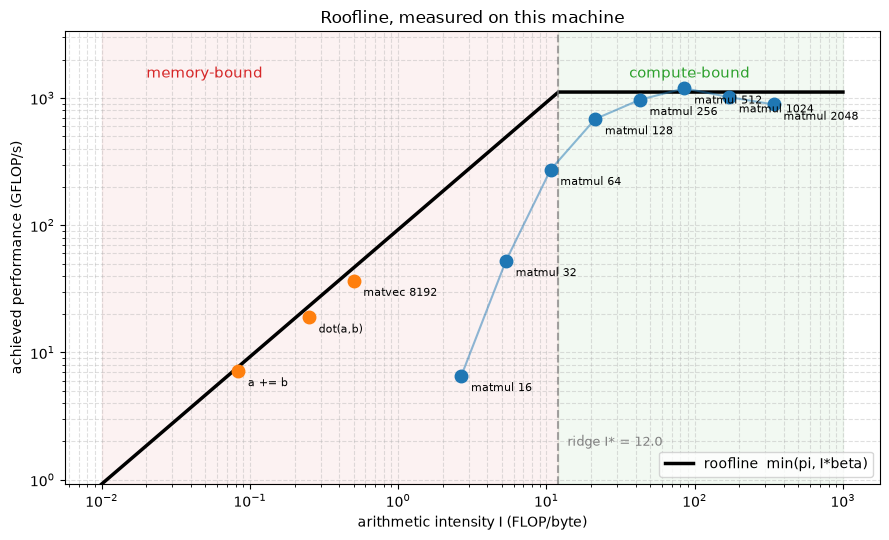

In [13]:
# The roofline plot.
I_grid = np.logspace(-2, 3, 400)
roof = np.minimum(peak_flops, I_grid * peak_bw) / 1e9

plt.figure(figsize=(9, 5.5))
plt.loglog(I_grid, roof, "k-", lw=2.5, label="roofline  min(pi, I*beta)")
plt.axvline(ridge, color="gray", ls="--", alpha=0.7)
plt.text(ridge * 1.15, roof.min() * 2, f"ridge I* = {ridge:.1f}", color="gray", fontsize=9)

# Shade the two regimes.
plt.axvspan(I_grid[0], ridge, alpha=0.06, color="tab:red")
plt.axvspan(ridge, I_grid[-1], alpha=0.06, color="tab:green")
plt.text(I_grid[0] * 2, peak_flops / 1e9 * 1.3, "memory-bound", color="tab:red", fontsize=11)
plt.text(ridge * 3, peak_flops / 1e9 * 1.3, "compute-bound", color="tab:green", fontsize=11)

mm = [(I, g) for name, I, g in kernels if name.startswith("matmul")]
plt.plot([p[0] for p in mm], [p[1] for p in mm], "-", color="tab:blue", alpha=0.5, lw=1.5)
for name, I, gflops in kernels:
    c = "tab:blue" if name.startswith("matmul") else "tab:orange"
    plt.plot(I, gflops, "o", ms=9, color=c)
    plt.annotate(name, (I, gflops), textcoords="offset points", xytext=(7, -11), fontsize=8)

plt.xlabel("arithmetic intensity I (FLOP/byte)")
plt.ylabel("achieved performance (GFLOP/s)")
plt.title("Roofline, measured on this machine")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend(loc="lower right")
plt.ylim(roof.min(), peak_flops / 1e9 * 3)
plt.tight_layout()

> **Observe:** The graph shows four important patterns.
>
> **1. The two parts of the roof have different shapes.** On the memory-bound
> side,
>
> $$
> P_{\text{roof}}=I\beta.
> $$
>
> Because the memory bandwidth $\beta$ is fixed, performance increases in direct
> proportion to arithmetic intensity. Doubling $I$ doubles the amount of
> computation performed for each byte supplied by memory, so the roof rises with
> slope 1 on the log-log plot. On the compute-bound side,
>
> $$
> P_{\text{roof}}=\pi.
> $$
>
> The machine cannot exceed its fixed peak compute throughput $\pi$, no matter how
> large $I$ becomes, so this part of the roof is horizontal. The two lines meet at
> the ridge point $I^*=\pi/\beta$.
>
> **2. The streaming kernels follow the sloped bandwidth roof.** Vector addition,
> dot product, and matrix-vector multiplication have low arithmetic intensity and
> remain on the left side of the ridge. Their performance is therefore largely
> constrained by memory bandwidth. Increasing peak compute throughput alone would
> not substantially raise their roofline limit.
>
> **3. Matrix multiplication moves toward the compute ceiling.** As $n$
> increases, the modeled intensity $I=n/6$ moves the matmul points to the right.
> Their performance rises rapidly and approaches the flat compute roof. Once a
> point crosses the ridge, the compute roof is lower than the bandwidth roof.
> Increasing arithmetic intensity further can no longer raise the roofline bound.
>
> **4. Real measurements do not follow the ideal roof perfectly.** Small matmuls
> lie far below the roof because per-call overhead and poor hardware utilization
> dominate their execution time. These costs are not represented by the basic
> roofline model. Cache behavior, threading, library implementation, processor
> frequency, and measurement variation also explain why the larger matmul points
> are not perfectly flat and why one point may appear slightly above the estimated
> roof.
>
> The main lesson is that high arithmetic intensity gives a kernel the opportunity
> to use the machine’s compute capacity, but it does not guarantee peak
> performance. Kernel fusion, which we examine shortly with `jit`, can improve
> memory-bound code by eliminating unnecessary reads and writes.

<!-- ### 🔬 Exercise 1

The **5-point stencil** `out[i,j] = 0.25*(u[i-1,j] + u[i+1,j] + u[i,j-1] + u[i,j+1])` is
the workhorse of PDE solvers and the ancestor of the convolution.

**Exercise:** Count its FLOPs and its DRAM bytes per output element (assume the
neighbours are re-read from DRAM, i.e. no cache reuse), compute its arithmetic intensity,
and predict from the roofline whether it is compute- or memory-bound. Then measure it.

You will find the measured rate falls **well short** of the roofline ceiling — much
further than the simple kernels in Section 4 did. Your real job is the follow-up: *why?*
Count how many arrays the NumPy expression actually materializes before it produces
`out`, and then test your explanation by running the identical expression under
`jax.jit`. -->


<!-- # --- Reference solution (instructor: blank this out for students) ---
# FLOPs per output: 3 adds + 1 multiply = 4.
# Bytes per output (pessimistic, no reuse): 4 neighbour reads + 1 write = 5 * 4B = 20 B.
I_stencil = 4 / 20

n = 4096
u = rng.standard_normal((n, n), dtype=np.float32)

def stencil(u):
    return 0.25 * (u[:-2, 1:-1] + u[2:, 1:-1] + u[1:-1, :-2] + u[1:-1, 2:])

u_j = jnp.array(u)
stencil_jit = jax.jit(stencil)
_ = stencil_jit(u_j).block_until_ready()  # compile before timing

t_np = bench(lambda: stencil(u), n_warmup=1, n_rep=3)
t_jit = bench(lambda: stencil_jit(u_j).block_until_ready(), n_warmup=1, n_rep=3)

n_out = (n - 2) * (n - 2)
g_np = 4 * n_out / t_np / 1e9
g_jit = 4 * n_out / t_jit / 1e9
roof_stencil = min(peak_flops, I_stencil * peak_bw) / 1e9

print(f"predicted I         : {I_stencil:.3f} FLOP/byte")
print(f"ridge point I*      : {ridge:.2f} FLOP/byte")
print(f"=> predicted regime : {'MEMORY-bound' if I_stencil < ridge else 'COMPUTE-bound'}")
print(f"roofline ceiling    : {roof_stencil:.1f} GFLOP/s")
print()
print(f"numpy   : {g_np:6.2f} GFLOP/s  ({100 * g_np / roof_stencil:3.0f}% of ceiling)")
print(f"jax.jit : {g_jit:6.2f} GFLOP/s  ({100 * g_jit / roof_stencil:3.0f}% of ceiling)")
print(f"fusion speedup: {t_np / t_jit:.2f}x")
print()
print("WHY numpy misses the ceiling: the expression is evaluated pairwise, so it")
print("materializes a full temporary array at every '+'. Roughly:")
print("    t1 = u[:-2,1:-1] + u[2:,1:-1]     -> writes ~64 MB")
print("    t2 = t1 + u[1:-1,:-2]             -> reads 64, writes 64 MB")
print("    t3 = t2 + u[1:-1,2:]              -> reads 64, writes 64 MB")
print("    out = 0.25 * t3                   -> reads 64, writes 64 MB")
print("Our I = 4/20 assumed ONE pass. NumPy makes four, so the real traffic is")
print("several times our estimate -- and the intensity is correspondingly lower.")
print("The roofline was right; our BYTE COUNT was wrong.")
print()
print("jax.jit fuses all of it into a single pass and recovers most of the gap,")
print("with no change to the expression itself. That is Section 7 in one line.") -->

## 5. CPU, GPU, and TPU architectures

The roofline model also applies to GPUs and TPUs. For a given numerical format,
each processor has a peak compute rate $\pi$ and a memory bandwidth $\beta$.
The architectures differ mainly in how they execute work and handle memory latency.

A **CPU** uses relatively complex cores with large caches, branch prediction, and
out-of-order execution. These features help a CPU run sequential and branch-heavy
programs with low latency.

A **GPU** is built to run many threads concurrently. Each streaming multiprocessor
keeps several warps ready. If one warp stalls while waiting for data, the scheduler
can issue instructions from another. This works well when the program contains
enough independent parallel work.

A **TPU** devotes much of its compute hardware to matrix operations. In a systolic
array, values move between neighboring multiply-accumulate units and are reused
during the matrix multiplication. This reduces data movement within the operation,
although inputs and results must still move through the memory hierarchy. Vector and
scalar units handle operations that do not run on the matrix unit.

```text
   CPU                         GPU                         TPU
┌────────────┐          ┌─┬─┬─┬─┬─┬─┬─┐            ┌────────────────┐
│ complex    │          ├─┼─┼─┼─┼─┼─┼─┤            │  systolic      │
│ cores      │          ├─┼─┼─┼─┼─┼─┼─┤            │  dataflow      │
│ + large    │          ├─┼─┼─┼─┼─┼─┼─┤            │  matrix units  │
│ caches     │          └─┴─┴─┴─┴─┴─┴─┘            └────────────────┘
└────────────┘          many parallel lanes          specialized ML dataflow

LOW-LATENCY,             PARALLEL                     MATRIX-HEAVY
GENERAL-PURPOSE          THROUGHPUT                   ML THROUGHPUT
```

  
These are architectural emphases rather than strict boundaries. CPUs also use
parallelism, GPUs have caches and complex schedulers, and TPUs execute operations
other than matrix multiplication.

The figures below are representative datasheet values. We use them to compare
compute-to-bandwidth ratios and ridge points, not as measurements of this machine.

In [19]:
# Representative specs (order-of-magnitude; dense, no sparsity tricks).
hw = [
    # name and compute path, peak TFLOP/s, bandwidth GB/s
    # GPU entries use dense FP16 Tensor Core throughput (no sparsity).
    ("CPU (FP32)",          2.0,          200),
    ("V100 (FP16 TC)",    125.0,          900),
    ("A100 (FP16 TC)",    312.0,         2039),
    ("H100 (FP16 TC)",    989.0,         3350),
    ("TPU v4 (BF16)",     275.0,         1200),
]

print(f'{"device":>14}  {"TFLOP/s":>8}  {"GB/s":>7}  {"ridge I*":>9}')
print("-" * 46)
for name, tf, gbs in hw:
    print(f"{name:>14}  {tf:>8.1f}  {gbs:>7.0f}  {tf * 1e12 / (gbs * 1e9):>9.1f}")

print()
print(f"this machine  : ridge I* = {ridge:.1f} FLOP/byte")

        device   TFLOP/s     GB/s   ridge I*
----------------------------------------------
    CPU (FP32)       2.0      200       10.0
V100 (FP16 TC)     125.0      900      138.9
A100 (FP16 TC)     312.0     2039      153.0
H100 (FP16 TC)     989.0     3350      295.2
 TPU v4 (BF16)     275.0     1200      229.2

this machine  : ridge I* = 12.0 FLOP/byte


V100 -> H100: compute x63.0, bandwidth x3.7, ridge x2.1


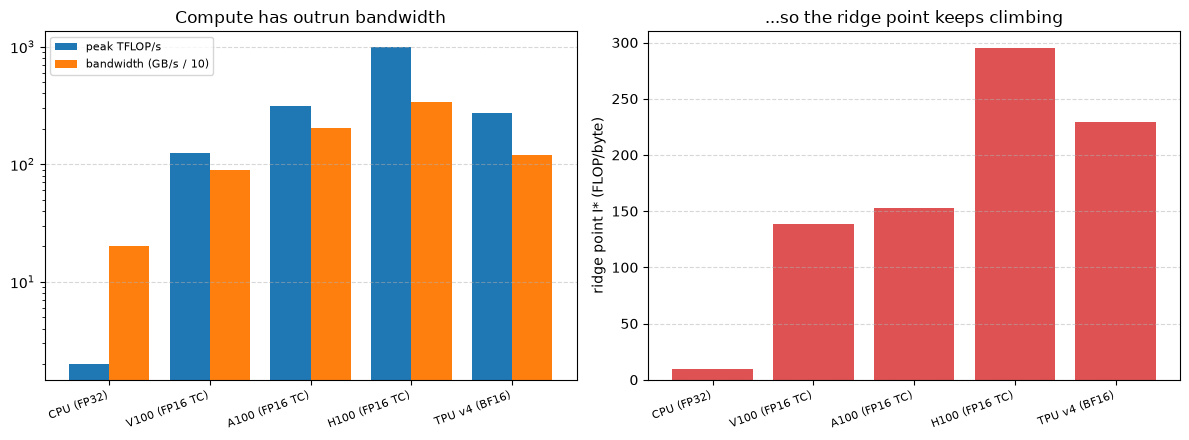

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

names = [h[0] for h in hw]
tflops = np.array([h[1] for h in hw])
bws = np.array([h[2] for h in hw])
ridges = tflops * 1e12 / (bws * 1e9)
xs = np.arange(len(hw))

ax = axes[0]
ax.bar(xs - 0.2, tflops, 0.4, label="peak TFLOP/s", color="tab:blue")
ax.bar(xs + 0.2, bws / 10, 0.4, label="bandwidth (GB/s / 10)", color="tab:orange")
ax.set_yscale("log")
ax.set_xticks(xs)
ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
ax.set_title("Compute has outrun bandwidth")
ax.grid(True, ls="--", alpha=0.5, axis="y")
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(xs, ridges, color="tab:red", alpha=0.8)
ax.set_xticks(xs)
ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("ridge point I* (FLOP/byte)")
ax.set_title("...so the ridge point keeps climbing")
ax.grid(True, ls="--", alpha=0.5, axis="y")

plt.tight_layout()

print(f"V100 -> H100: compute x{989 / 15.7:.1f}, bandwidth x{3350 / 900:.1f}, ridge x{ridges[3] / ridges[1]:.1f}")

**Observe:** A hardware comparison is meaningful only when the compute path and
> numerical format match. Using dense FP16 Tensor Core throughput for all three NVIDIA
> GPUs, peak compute increased by about **7.9x** from V100 to H100, while HBM bandwidth
> increased by about **3.7x**. The corresponding ridge point rose from roughly
> $139$ to $295$ FLOP/byte, an increase of about **2.1x**.
>
> For this compute path, a kernel with intensity between those two ridge points can lie on
> the compute side of the V100 roofline but on the bandwidth side of the H100 roofline.
> Faster tensor arithmetic has therefore increased the amount of data reuse needed to
> reach the compute roof. Fusion, tiling, and batching can help when they reduce DRAM
> traffic or reuse each fetched value more often.
>
> This trend depends on the operation and numerical format; it is not a universal claim
> about every instruction on every newer accelerator. FlashAttention is a useful example:
> it is an I/O-aware attention algorithm that uses tiling to reduce reads and writes
> between HBM and on-chip memory.

---

## 6. NumPy → JAX: the same array API, three different rules

Now we meet the tool. JAX's surface is deliberately NumPy — `jnp.sum`, `jnp.reshape`,
broadcasting, all where you expect. That familiarity is a trap worth defusing early,
because **three rules underneath are different**, and each one bites a newcomer exactly
once.

| | NumPy | JAX |
|---|---|---|
| mutation | `x[0] = 1` works | arrays are **immutable**; use `x.at[0].set(1)` |
| default float | `float64` | **`float32`** |
| execution | synchronous | **asynchronous dispatch** |
| randomness | global implicit state | **explicit `key`**, split by hand |

Let us take them one at a time, because each has a real reason behind it.


In [14]:
# --- Rule 1: immutability ---
x_np = np.zeros(5)
x_np[0] = 1.0  # fine
print("numpy in-place :", x_np)

x_jax = jnp.zeros(5)
try:
    x_jax[0] = 1.0
except TypeError as e:
    print("jax in-place   : TypeError ->", str(e).split(".")[0])

# The functional replacement: .at[].set() RETURNS A NEW ARRAY.
y = x_jax.at[0].set(1.0)
print("x_jax (unchanged):", x_jax)
print("y = x.at[0].set(1):", y)

numpy in-place : [1. 0. 0. 0. 0.]
jax in-place   : TypeError -> JAX arrays are immutable and do not support in-place item assignment


x_jax (unchanged): [0. 0. 0. 0. 0.]
y = x.at[0].set(1): [1. 0. 0. 0. 0.]


Immutability looks like a tax until you see what it buys. A compiler that knows an array
is never mutated can reorder operations, fuse them, and place them on any device without
proving that no one else is watching. **Functional purity is what makes `jit`, `grad`,
`vmap`, and sharding all composable** — every transformation in this course rests on it.

And it is not actually a copy: under `jit`, `.at[].set()` compiles to an in-place update
when the old value is dead. You write functional code; XLA writes the mutation.


In [15]:
# --- Rule 2: float32 by default ---
print("numpy dtype:", np.zeros(3).dtype)
print("jax dtype  :", jnp.zeros(3).dtype)

# This silently halves your precision if you port code without noticing.
x64 = np.array([1.0 + 1e-10], dtype=np.float64)
x32 = jnp.array([1.0 + 1e-10])
print()
print(f"float64 1 + 1e-10 - 1 = {(x64 - 1)[0]:.3e}   (resolved)")
print(f"float32 1 + 1e-10 - 1 = {float((x32 - 1)[0]):.3e}   (vanished)")
print()
print("float32 eps:", np.finfo(np.float32).eps)
print("float64 eps:", np.finfo(np.float64).eps)
print()
print("To opt into float64:  jax.config.update('jax_enable_x64', True)")
print("(We leave it off -- ML wants speed, and accelerators are built for float32/bf16.)")

numpy dtype: float64
jax dtype  : float32

float64 1 + 1e-10 - 1 = 1.000e-10   (resolved)
float32 1 + 1e-10 - 1 = 0.000e+00   (vanished)

float32 eps: 1.1920929e-07
float64 eps: 2.220446049250313e-16

To opt into float64:  jax.config.update('jax_enable_x64', True)
(We leave it off -- ML wants speed, and accelerators are built for float32/bf16.)


> **Observe:** `1 + 10^{-10}` is simply **equal to 1** in float32. That is not a bug;
> it is the deliberate bargain of machine learning. Gradient descent is a
> noise-tolerant, self-correcting process, so it does not need 16 digits — and giving up
> those digits buys a 2x cut in memory traffic (which, per Section 4, is what actually
> limits you) and access to hardware matmul units. Modern training pushes this further
> still, to **bfloat16**: same exponent range as float32, far fewer mantissa bits.
>
> The trap is porting *numerical* code — an ODE solver, a physics simulation — where
> float32 quietly destroys your answer. Know which kind of code you are writing.


In [16]:
# --- Rule 3: asynchronous dispatch (the benchmarking trap) ---
n = 2048
A = jnp.array(rng.standard_normal((n, n), dtype=np.float32))
B = jnp.array(rng.standard_normal((n, n), dtype=np.float32))

_ = (A @ B).block_until_ready()  # warm up

t_async = bench(lambda: A @ B)                                  # WRONG
t_sync = bench(lambda: (A @ B).block_until_ready())             # RIGHT

print(f"without block_until_ready : {t_async * 1e3:8.3f} ms  <- times DISPATCH")
print(f"with    block_until_ready : {t_sync * 1e3:8.3f} ms  <- times COMPUTE")
print(f"apparent speedup from lying to yourself: {t_sync / t_async:.1f}x")
print()
print(f"honest GFLOP/s: {2 * n**3 / t_sync / 1e9:.1f}")
print(f"'GFLOP/s' if you forget: {2 * n**3 / t_async / 1e9:.1f}  (physically impossible)")

without block_until_ready :    0.010 ms  <- times DISPATCH
with    block_until_ready :   32.142 ms  <- times COMPUTE
apparent speedup from lying to yourself: 3200.8x

honest GFLOP/s: 534.5
'GFLOP/s' if you forget: 1710804.0  (physically impossible)


> **Observe:** JAX operations return a **future**, not a result. The Python call returns
> as soon as the work is *queued*, so a naive timer measures how fast Python can ask for
> a matmul — not how fast the matmul runs. Above, forgetting `block_until_ready()`
> reports a rate that would beat the machine's measured peak by a wide margin: the number
> is not merely optimistic, it is **impossible**, which is the tell.
>
> Async dispatch is a feature — it lets Python run ahead and keep the accelerator queue
> full. But it means **every timing cell in this course must call `block_until_ready()`**.
> This is the single most common way benchmarks in the JAX ecosystem end up wrong.


In [17]:
# --- Rule 4: explicit PRNG ---
# NumPy: hidden global state. Same call, different answers.
np.random.seed(0)
print("numpy: ", np.random.randn(2), np.random.randn(2), " <- differ (state advanced)")

# JAX: a key IS the state. Same key -> same numbers, always. Reproducible by construction.
k = jax.random.key(0)
print("jax:   ", jax.random.normal(k, (2,)), jax.random.normal(k, (2,)), " <- IDENTICAL")

# To get fresh randomness you must SPLIT, explicitly.
k1, k2 = jax.random.split(k)
print("split: ", jax.random.normal(k1, (2,)), jax.random.normal(k2, (2,)), " <- differ")

numpy:  [1.76405235 0.40015721] [0.97873798 2.2408932 ]  <- differ (state advanced)
jax:    [1.6226422 2.0252647] [1.6226422 2.0252647]  <- IDENTICAL
split:  [ 1.0040143 -0.9063372] [-2.4424558 -2.0356805]  <- differ


> **Observe:** Reusing a key silently gives you the *same* "random" numbers — a bug that
> is invisible until your dropout masks are identical across layers. The discipline is:
> **split every time, never reuse.** The payoff is that PRNG state becomes an explicit
> value you can pass around, which is why it is one of the four pieces of state we track
> from Week 3 onward (parameters · optimizer state · batch stats · **PRNG**). When a
> client in Week 9 needs reproducible local training, this is what makes it possible.


### 🔬 Exercise 2

**Exercise:** Port this NumPy function to JAX. It mutates its input in a loop, uses
global randomness, and returns float64 — every rule from this section, in six lines.

```python
def noisy_normalize_np(x, n_steps=3):
    x = x.copy()
    for _ in range(n_steps):
        x += 0.1 * np.random.randn(*x.shape)   # global RNG
        x[x < 0] = 0.0                         # in-place mutation
        x /= (x.max() + 1e-8)                  # in-place division
    return x
```

Your JAX version must take an explicit `key`, use no in-place mutation, and give
identical results when called twice with the same key.


In [18]:
# --- Reference solution (instructor: blank this out for students) ---
def noisy_normalize_np(x, n_steps=3):
    x = x.copy()
    for _ in range(n_steps):
        x += 0.1 * np.random.randn(*x.shape)
        x[x < 0] = 0.0
        x /= (x.max() + 1e-8)
    return x


def noisy_normalize_jax(x, key, n_steps=3):
    for _ in range(n_steps):
        key, subkey = jax.random.split(key)          # split, never reuse
        x = x + 0.1 * jax.random.normal(subkey, x.shape)  # rebind, don't mutate
        x = jnp.maximum(x, 0.0)                      # functional replacement for x[x<0]=0
        x = x / (x.max() + 1e-8)
    return x


x0 = rng.standard_normal(6, dtype=np.float32)
k = jax.random.key(42)

out1 = noisy_normalize_jax(jnp.array(x0), k)
out2 = noisy_normalize_jax(jnp.array(x0), k)
print("call 1:", np.asarray(out1))
print("call 2:", np.asarray(out2))
print("reproducible:", bool(jnp.all(out1 == out2)))
print("dtype:", out1.dtype)
print()
np.random.seed(0)
print("numpy version (not reproducible without reseeding):", noisy_normalize_np(x0.astype(np.float64)))

call 1: [0.         0.75173926 0.         0.         0.41752502 1.        ]
call 2: [0.         0.75173926 0.         0.         0.41752502 1.        ]
reproducible: True
dtype: float32

numpy version (not reproducible without reseeding): [0.16238136 0.7991119  0.04531602 0.07066391 0.16537627 0.99999999]


---

## 7. What `jit` actually buys, and why

Now we can close the loop between the roofline and the tool. `jax.jit` traces your
Python function once, hands the resulting graph to **XLA**, and gets back a single
compiled kernel. Two things happen, and only one of them is the interesting one:

1. **Dispatch overhead disappears.** One compiled call replaces $k$ trips through
   Python. This matters for small arrays.
2. **Operations fuse.** A chain of elementwise ops becomes *one* pass over memory
   instead of $k$ passes with $k-1$ temporary arrays in between.

Reason 2 is the one that connects to everything we measured. Write $c$ for the (small)
number of FLOPs one step costs per element. Un-fused, a chain of $k$ steps over $n$
float32 elements moves roughly $2 \cdot 4nk$ bytes — each step reads its input and writes
a temporary — for about $c\,nk$ FLOPs, giving intensity $\approx c/8$: a constant,
independent of $k$, pinned to the far left of the roofline. Fused, it reads $4n$ and
writes $4n$ **once**, for the same $c\,nk$ FLOPs — intensity $\approx c\,k/8$.

**Fusion multiplies arithmetic intensity by $k$.** That is not a constant-factor trick;
it moves the kernel rightward along the roofline. Let us watch it happen.

The choice of operation matters, and it is worth being explicit about why. We use
`0.99*x + 0.01*|x|`: it is **cheap** (a few FLOPs per element, so the chain really is
memory-bound and fusion has something to win) and **non-foldable** (the `abs` makes it
piecewise, so XLA cannot algebraically collapse the chain into a single affine map and
make the experiment meaningless). A chain of `tanh` behaves quite differently, and finding
out why is one of the Further Exercises.


In [19]:
# A chain of CHEAP elementwise ops: lots of memory traffic, little arithmetic.
def step(v):
    return 0.99 * v + 0.01 * jnp.abs(v)


def chain(x):
    for _ in range(10):
        x = step(x)
    return x


chain_jit = jax.jit(chain)

n = 4_000_000
x = jnp.array(rng.standard_normal(n, dtype=np.float32))

# Compilation is a real, one-time cost -- time it separately, never inside the loop.
t0 = time.perf_counter()
_ = chain_jit(x).block_until_ready()
t_compile = time.perf_counter() - t0

t_eager = bench(lambda: chain(x).block_until_ready())
t_jit = bench(lambda: chain_jit(x).block_until_ready())

print(f"compile once : {t_compile * 1e3:8.2f} ms")
print(f"eager        : {t_eager * 1e3:8.2f} ms")
print(f"jit          : {t_jit * 1e3:8.2f} ms")
print(f"speedup      : {t_eager / t_jit:8.2f}x")
print()
print(f"compile pays for itself after {t_compile / (t_eager - t_jit):.1f} calls")
print()
print("correctness check:", bool(jnp.allclose(chain(x), chain_jit(x), atol=1e-5)))

compile once :    34.73 ms
eager        :    33.71 ms
jit          :     1.18 ms
speedup      :    28.59x

compile pays for itself after 1.1 calls

correctness check: True


In [20]:
# Does the speedup grow with chain length, as the fusion argument predicts?
lengths = [1, 2, 5, 10, 20, 40]
speedups, eager_ts, jit_ts = [], [], []

for k in lengths:
    def make(k):
        def f(x):
            for _ in range(k):
                x = step(x)
            return x
        return f

    f = make(k)
    fj = jax.jit(f)
    _ = fj(x).block_until_ready()  # compile

    te = bench(lambda: f(x).block_until_ready(), n_rep=3)
    tj = bench(lambda: fj(x).block_until_ready(), n_rep=3)
    eager_ts.append(te * 1e3)
    jit_ts.append(tj * 1e3)
    speedups.append(te / tj)

print(f'{"chain len k":>11}  {"eager ms":>9}  {"jit ms":>8}  {"speedup":>8}')
print("-" * 44)
for k, te, tj, s in zip(lengths, eager_ts, jit_ts, speedups):
    print(f"{k:>11}  {te:>9.2f}  {tj:>8.2f}  {s:>7.2f}x")

chain len k   eager ms    jit ms   speedup
--------------------------------------------
          1       3.59      0.70     5.14x
          2       6.58      0.76     8.64x
          5      16.72      0.75    22.39x
         10      32.72      1.18    27.68x
         20      65.11      3.31    19.70x
         40     130.54      8.48    15.39x


best speedup: 27.7x at k = 10


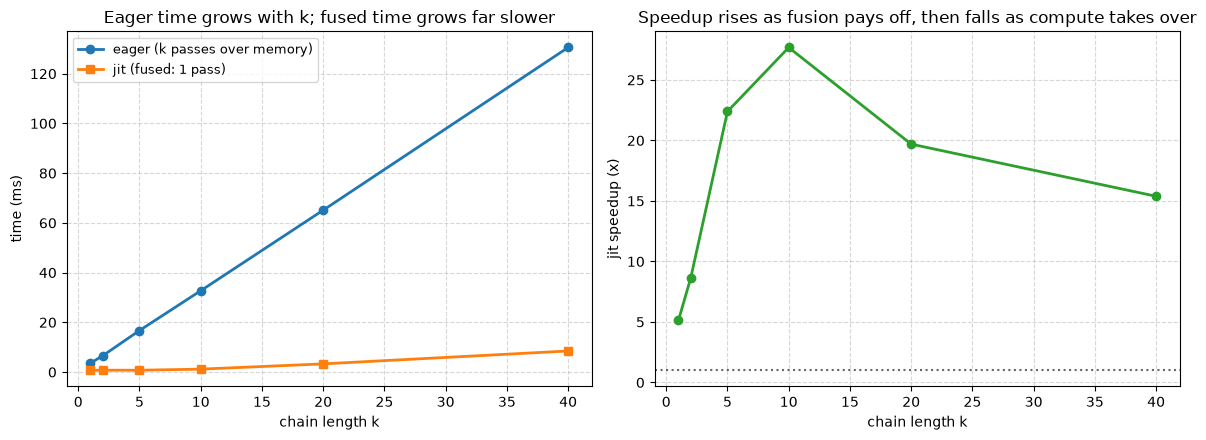

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(lengths, eager_ts, "o-", lw=2, label="eager (k passes over memory)")
ax.plot(lengths, jit_ts, "s-", lw=2, label="jit (fused: 1 pass)")
ax.set_xlabel("chain length k")
ax.set_ylabel("time (ms)")
ax.set_title("Eager time grows with k; fused time grows far slower")
ax.grid(True, ls="--", alpha=0.5)
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(lengths, speedups, "o-", lw=2, color="tab:green")
ax.axhline(1.0, color="k", ls=":", alpha=0.6)
ax.set_xlabel("chain length k")
ax.set_ylabel("jit speedup (x)")
ax.set_title("Speedup rises as fusion pays off, then falls as compute takes over")
ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()

print(f"best speedup: {max(speedups):.1f}x at k = {lengths[int(np.argmax(speedups))]}")

> **Observe:** Look at the two curves separately, because they tell different halves of
> the story.
>
> **Eager grows linearly in $k$** — each extra operation is another full round-trip to
> DRAM, and the cost is dead honest about it. **Fused grows far more slowly**: going from
> $k=1$ to $k=5$ costs the compiled version almost nothing, because those five operations
> collapse into the *same single pass* over the data. That is fusion, visible in the
> timings.
>
> **But the speedup is not monotonic** — it rises steeply, peaks, and then declines. This
> is worth understanding rather than explaining away, because it is the roofline talking.
> At small $k$ the fused kernel is still memory-bound, so removing memory traffic is pure
> profit. As $k$ grows, fusion multiplies the intensity by $k$ and eventually drags the
> kernel *past the ridge*: the fused version becomes **compute-bound**, at which point
> there is no memory traffic left to remove and its time starts growing linearly in $k$
> too. Fusion cannot help you once you are compute-bound. It has already done its job.
>
> So `jit` is not "a magic speed flag". It is a **roofline intervention**: it drags a
> memory-bound kernel rightward by eliminating traffic between operations, and its payoff
> is largest exactly when you start furthest left. That is a *predictive* statement — you
> can now say in advance that a long chain of cheap elementwise ops will win big, and that
> a single large matmul (already compute-bound, Section 4) will win almost nothing.


In [22]:
# The OTHER benefit: dispatch overhead. Tiny arrays -> Python is the bottleneck.
print(f'{"array size":>11}  {"eager us":>9}  {"jit us":>8}  {"speedup":>8}')
print("-" * 42)
for n_small in [10, 100, 1_000, 10_000, 100_000, 1_000_000]:
    xs = jnp.array(rng.standard_normal(n_small, dtype=np.float32))
    f = lambda v: jnp.tanh(v) + 0.5 * v
    fj = jax.jit(f)
    _ = fj(xs).block_until_ready()

    te = bench(lambda: f(xs).block_until_ready(), n_rep=5)
    tj = bench(lambda: fj(xs).block_until_ready(), n_rep=5)
    print(f"{n_small:>11}  {te * 1e6:>9.1f}  {tj * 1e6:>8.1f}  {te / tj:>7.2f}x")

 array size   eager us    jit us   speedup
------------------------------------------


         10       23.9       5.6     4.24x


        100       24.4       5.8     4.22x


       1000       31.6       6.5     4.83x


      10000       50.0      29.5     1.69x


     100000      142.2      53.8     2.64x


    1000000      966.5     309.6     3.12x


> **Observe:** Across the smallest sizes the times **barely depend on size at all** —
> 10 elements and 1000 elements cost the same. Each version is pinned at its own fixed
> floor (jitted noticeably lower than eager, since one compiled call replaces several
> dispatches). That floor is **not** the arithmetic — a `tanh` over 10 elements is
> nothing; it is the fixed cost of dispatching work from Python. Below it, array size is
> irrelevant and you are timing the interpreter.
>
> Two lessons. First, **many small operations are the enemy** — this is why Week 4 turns
> a Python training loop into `jax.lax.scan`, moving the loop itself inside the compiled
> region. Second, this is your first encounter with a theme that will follow us all the
> way to federated learning: **the fixed cost per operation dominates when the operation
> is small.** In Week 10 the same arithmetic reappears with bytes-on-the-wire instead of
> microseconds — a federated round that sends a tiny update still pays the full round-trip
> latency, which is why we batch τ local steps before communicating.


### 🔬 Exercise 3

**Exercise:** `jit` has a cost we have been quietly paying: **compilation is triggered
per input shape**. Every new shape retraces and recompiles the function.

Call a jitted function on 5 different array shapes, timing each *first* call, then call
them all again. Which calls are slow, and why? What does this imply for a training loop
whose final batch is smaller than the others?


In [23]:
# --- Reference solution (instructor: blank this out for students) ---
@jax.jit
def f(v):
    return jnp.sum(jnp.tanh(v) + 0.5 * v)


shapes = [(100,), (200,), (300,), (400,), (500,)]
arrs = [jnp.array(rng.standard_normal(s, dtype=np.float32)) for s in shapes]

print("FIRST call on each shape (compiles):")
first = []
for s, a in zip(shapes, arrs):
    t0 = time.perf_counter()
    _ = f(a).block_until_ready()
    dt = (time.perf_counter() - t0) * 1e3
    first.append(dt)
    print(f"  shape {str(s):>8}: {dt:8.2f} ms")

print("\nSECOND call on each shape (cache hit):")
second = []
for s, a in zip(shapes, arrs):
    t0 = time.perf_counter()
    _ = f(a).block_until_ready()
    dt = (time.perf_counter() - t0) * 1e3
    second.append(dt)
    print(f"  shape {str(s):>8}: {dt:8.2f} ms")

print(f"\nmedian first call : {np.median(first):8.2f} ms")
print(f"median second call: {np.median(second):8.3f} ms")
print(f"compilation is ~{np.median(first) / np.median(second):.0f}x the execution cost here")
print()
print("Implication: a training loop whose last batch is a different shape recompiles")
print("the ENTIRE step function for that one batch. Standard fix: drop the ragged")
print("last batch, or pad it to full size. Week 4 explores this trap in depth.")

FIRST call on each shape (compiles):


  shape   (100,):    46.15 ms
  shape   (200,):    32.27 ms
  shape   (300,):    32.86 ms
  shape   (400,):    30.85 ms


  shape   (500,):    31.11 ms

SECOND call on each shape (cache hit):
  shape   (100,):     0.19 ms
  shape   (200,):     0.04 ms
  shape   (300,):     0.02 ms
  shape   (400,):     0.04 ms
  shape   (500,):     0.03 ms

median first call :    32.27 ms
median second call:    0.036 ms
compilation is ~902x the execution cost here

Implication: a training loop whose last batch is a different shape recompiles
the ENTIRE step function for that one batch. Standard fix: drop the ragged
last batch, or pad it to full size. Week 4 explores this trap in depth.


## 8. Roadmap

The course begins with training on one device and then moves to settings in which
computation, data, or both are distributed.

```text
   Machine Learning
        │  gradient-based learning uses derivatives
        ▼
   Automatic Differentiation                       Week 2   (Lab 1)
        │  JAX transforms and compiles these computations
        ▼
   JAX Ecosystem                                   Weeks 3–4 (Labs 2–3)  [Stage 1]
        │  models and workloads may exceed one device
        ▼
   Distributed Training and Optimization           Weeks 5–7 (Labs 4–6)  [Stages 2–3]
        │  training data may have to remain local
        ▼
   Federated Learning                              Weeks 8–11 (Labs 7–9) [Stages 4–5]
        │  privacy and robustness still need to be addressed
        ▼
   Trustworthy Federated Learning                  Weeks 12–14 (Labs 10–11) [Stages 6–7]
        │
        ▼
   Federated Foundation Models                     Weeks 15–16
```

Week 7 introduces Local SGD: each worker takes $\tau$ local steps before the
models are averaged. FedAvg uses the same local-update-and-average pattern. The two
have the same update form under full participation, equal local work, and suitable
weighting. Federated learning must also account for non-IID data, partial
participation, unequal dataset sizes, and differences in client hardware.

The implementation also develops across the semester. We start with an Equinox
training loop in Week 3, then add sharding, local updates, federated aggregation,
compression, privacy mechanisms, and Byzantine clients.

The roofline applies directly to computation and DRAM traffic within one device.
Distributed training introduces a similar trade-off at a different level. Sharding
determines which data crosses an interconnect, Local SGD reduces the frequency of
communication, and compression reduces the number of transmitted bytes. These
problems require communication models in addition to the roofline. Federated
learning also introduces statistical, privacy, and security questions that the
roofline does not address.

In [22]:
# One more preview: the gradient. This is Week 2, and it is why JAX exists at all.
def rosenbrock(v):
    return (1 - v[0]) ** 2 + 100 * (v[1] - v[0] ** 2) ** 2


v = jnp.array([0.5, 0.5])
grad_fn = jax.grad(rosenbrock)
hess_fn = jax.hessian(rosenbrock)

print("f(v)      =", float(rosenbrock(v)))
print("grad f(v) =", np.asarray(grad_fn(v)))
print("hess f(v) =\n", np.asarray(hess_fn(v)))

# Check the gradient against a finite difference -- the numbers should agree.
eps = 1e-4
fd = np.array([
    float((rosenbrock(v.at[i].add(eps)) - rosenbrock(v.at[i].add(-eps))) / (2 * eps))
    for i in range(2)
])
print("\nfinite-diff grad:", fd)
print("max |AD - FD|   :", float(np.max(np.abs(np.asarray(grad_fn(v)) - fd))))
print("\nNo derivative was written by hand. Note .at[i].add() -- immutability again.")

f(v)      = 6.5
grad f(v) = [-51.  50.]
hess f(v) =
 [[ 102. -200.]
 [-200.  200.]]

finite-diff grad: [-50.9929657   49.99876022]
max |AD - FD|   : 0.0070343017578125

No derivative was written by hand. Note .at[i].add() -- immutability again.


> **Observe:** `jax.grad` produced an exact gradient of a function we wrote as plain
> Python, and it agrees with a finite difference to the precision float32 allows. Note
> what did *not* happen: nobody derived $\partial f/\partial x$ on paper, and nobody
> chose a step size $\epsilon$. Next week we will see that reverse-mode AD delivers *all*
> $n$ partial derivatives for the cost of about one function evaluation — while the
> finite-difference check we just ran needs $2n$. That asymmetry is the entire reason
> training billion-parameter models is possible.


### 🔬 Exercise 4

**Exercise:** Put a transformer's feed-forward block on the roofline. For batch $B$,
sequence length $S$, model width $d$, and hidden width $4d$, the block computes
$X W_1 W_2$ with $X \in \mathbb{R}^{(BS) \times d}$, $W_1 \in \mathbb{R}^{d \times 4d}$,
$W_2 \in \mathbb{R}^{4d \times d}$.

Compute its arithmetic intensity as a function of the token count $T = BS$ and the width
$d$, and determine: for $d = 1024$, how many tokens must you process per call to be
compute-bound on **this machine**? On an **H100** ($I^{*} \approx 295$)? What does your
answer say about small batches?


In [25]:
# --- Reference solution (instructor: blank this out for students) ---
# FLOPs : 2*T*d*4d (first matmul) + 2*T*4d*d (second) = 16*T*d^2
# Bytes : X in (4*T*d) + W1 (4*4d^2) + W2 (4*4d^2) + out (4*T*d) = 8*T*d + 32*d^2
# I(T,d) = 16*T*d^2 / (8*T*d + 32*d^2)
def ffn_intensity(T, d):
    flops = 16 * T * d**2
    byts = 8 * T * d + 32 * d**2
    return flops / byts


d = 1024
Ts = np.array([1, 8, 64, 512, 4096, 32768, 262144], dtype=float)
Is = np.array([ffn_intensity(T, d) for T in Ts])

RIDGE_H100 = 295.0
print(f"Transformer FFN, d = {d}")
print(f'{"tokens T":>9}  {"I (F/B)":>9}  {"this machine":>13}  {"H100":>9}')
print("-" * 48)
for T, I in zip(Ts, Is):
    here = "compute" if I > ridge else "MEMORY"
    h100 = "compute" if I > RIDGE_H100 else "MEMORY"
    print(f"{T:>9.0f}  {I:>9.1f}  {here:>13}  {h100:>9}")

# Solve I(T,d) = ridge for T:  16*T*d^2 = R*(8*T*d + 32*d^2)
def tokens_needed(R, d):
    denom = 16 * d**2 - R * 8 * d
    return np.inf if denom <= 0 else R * 32 * d**2 / denom

print()
print(f"tokens needed on this machine (I* = {ridge:.1f}): {tokens_needed(ridge, d):.0f}")
print(f"tokens needed on an H100      (I* = {RIDGE_H100:.0f}): {tokens_needed(RIDGE_H100, d):.0f}")
print()
print(f"Large-T limit: I -> 2d = {2 * d} (weight reads amortized over many tokens).")
print(f"Small-T limit: I -> T/2, so I = {ffn_intensity(1.0, d):.1f} at T = 1.")
print()
print("That small-T limit is the whole story of LLM inference. At T = 1 you read all")
print(f"{2 * 4 * 4 * d**2 / 1e6:.0f} MB of W1 and W2 just to process a SINGLE token, and then throw")
print("them away. Intensity 0.5 is off the left edge of the roofline: decoding is")
print("hopelessly memory-bound, which is why batching and KV-caching dominate serving.")
print("Training with large batches lives on the right; decoding never does.")

Transformer FFN, d = 1024
 tokens T    I (F/B)   this machine       H100
------------------------------------------------
        1        0.5         MEMORY     MEMORY
        8        4.0         MEMORY     MEMORY
       64       31.5        compute     MEMORY
      512      227.6        compute     MEMORY
     4096     1024.0        compute    compute
    32768     1820.4        compute    compute
   262144     2016.5        compute    compute

tokens needed on this machine (I* = 13.1): 26
tokens needed on an H100      (I* = 295): 689

Large-T limit: I -> 2d = 2048 (weight reads amortized over many tokens).
Small-T limit: I -> T/2, so I = 0.5 at T = 1.

That small-T limit is the whole story of LLM inference. At T = 1 you read all
34 MB of W1 and W2 just to process a SINGLE token, and then throw
them away. Intensity 0.5 is off the left edge of the roofline: decoding is
hopelessly memory-bound, which is why batching and KV-caching dominate serving.
Training with large batches lives on

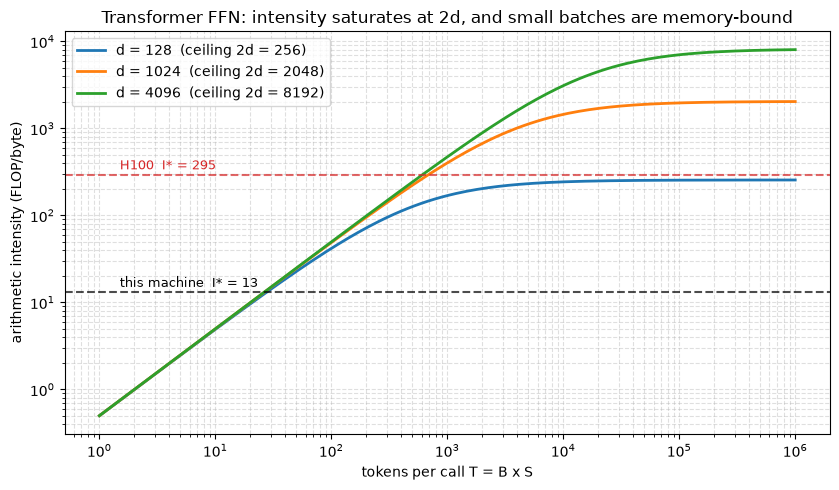

In [26]:
# Visualize it: intensity vs token count, against both machines' ridges.
Tg = np.logspace(0, 6, 200)
plt.figure(figsize=(8.5, 5))
for dd, c in [(128, "tab:blue"), (1024, "tab:orange"), (4096, "tab:green")]:
    plt.loglog(Tg, [ffn_intensity(T, dd) for T in Tg], lw=2, color=c,
               label=f"d = {dd}  (ceiling 2d = {2 * dd})")

plt.axhline(ridge, color="k", ls="--", alpha=0.7)
plt.text(1.5, ridge * 1.15, f"this machine  I* = {ridge:.0f}", fontsize=9)
plt.axhline(RIDGE_H100, color="tab:red", ls="--", alpha=0.7)
plt.text(1.5, RIDGE_H100 * 1.15, f"H100  I* = {RIDGE_H100:.0f}", fontsize=9, color="tab:red")

plt.xlabel("tokens per call T = B x S")
plt.ylabel("arithmetic intensity (FLOP/byte)")
plt.title("Transformer FFN: intensity saturates at 2d, and small batches are memory-bound")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()

> **Observe:** Under our idealized traffic model,
>
> $$
> I(T,d)=\frac{2Td}{T+4d}.
> $$
>
> When $T$ is small relative to $d$, $I(T,d)\approx T/2$. The weights are
> read for only a few tokens, so there is little opportunity to reuse them. As
> $T$ increases, the same weights are reused across more tokens and their loading
> cost is amortized. In the limit,
>
> $$
> \lim_{T\to\infty} I(T,d)=2d.
> $$
>
> This limit comes from the traffic assumptions used in the calculation. We count
> one read of each weight matrix and the input and output activations, while assuming
> that the intermediate activation between $W_1$ and $W_2$ does not have to be
> written to and read from DRAM. A real implementation may move more data and
> therefore achieve a lower intensity.
>
> For $d=128$, the modeled intensity approaches $256$ FLOP/byte. This remains
> below the H100 ridge point of approximately $295$ FLOP/byte, so this particular
> FFN cannot cross to the compute side of the H100 roofline under the stated model.
> Wider FFNs have a higher limiting intensity and can cross the ridge when enough
> tokens are processed together.
>
> The relevant quantity is $T=BS$, the number of tokens processed per call—not
> batch size alone. Increasing either the batch size or sequence length can improve
> weight reuse. The actual crossover depends on the kernel implementation, cache
> behavior, fusion, numerical format, and whether intermediate activations are
> written to DRAM.
>
> Federated clients often use small local batches, so some client-side operations
> may run at low arithmetic intensity. This is common in cross-device federated
> learning, but it is not a defining property of all federated systems.

<!-- ---

## Summary

Today we did no learning at all, and instead built the measuring instruments the rest of
the course depends on.

- **The scale gap is arithmetic, not vibes.** $C \approx 6 N_{\text{params}} N_{\text{tokens}}$
  puts modern models at tens of device-years. Parallelism is not an optimization; it is
  the only way the training finishes.
- **Bandwidth is a hierarchy, not a number.** We measured the staircase from cache to
  DRAM. Where your data lives when you touch it decides how fast your code is.
- **The roofline predicts which limit binds.** $P(I) = \min(\pi, I\beta)$, with the ridge
  $I^{*} = \pi/\beta$ as the machine's personality. We measured both roofs; no kernel
  broke the roof; streaming kernels hugged the slant while matmul walked across the ridge
  as $I = n/6$ and flattened. That is the reason ML is written as big dense matmuls.
- **And the roofline has a domain of validity.** The tiniest matmuls fell far below both
  roofs, because they were limited by a cost the model does not represent: per-call
  dispatch overhead. Know where your model stops applying.
- **Hardware is making this harder.** Compute grew ~63x from V100 to H100 while bandwidth
  grew ~3.7x. The ridge keeps climbing, so keeping a new accelerator busy takes more work,
  not less.
- **JAX changes four rules**: immutability (which is what makes `jit`/`grad`/`vmap`/sharding
  composable), float32 by default, async dispatch (**always `block_until_ready()`**), and
  explicit PRNG keys.
- **`jit` is a roofline intervention.** Fusion turns $k$ passes over memory into one,
  multiplying arithmetic intensity by $k$. Its payoff is largest when you start furthest
  left, and it *vanishes* once fusion has pushed you past the ridge — which is exactly why
  the measured speedup rose, peaked, and then fell.

The thread to hold: **every stage of this course is a fight over a ratio between compute
and communication.** Today the "communication" was DRAM. In Week 5 it becomes NVLink. In
Week 10 it becomes the internet, and a client on a phone. The unit changes; the arithmetic
does not.

Next week we descend one level: **automatic differentiation**, the engine underneath all
of it, and the cost asymmetry between forward and reverse mode that makes training
large models tractable.

### Further Exercises

1. **(Pencil)** Derive the ridge point at which a matrix-vector product could *ever* be
   compute-bound. Show it cannot be on any machine with $I^{*} > 0.5$, and conclude that
   `matvec` is memory-bound on every accelerator ever shipped.
2. **(Pencil)** A batch-norm layer reads $n$ activations and writes $n$, doing ~8 FLOPs
   each. Compute $I$ and explain why fusing it into the preceding convolution is worth
   real engineering effort.
3. **(Numerical)** Rerun the Section 2.2 gather sweep with float64 instead of float32. Do
   the cliffs move, and in which direction? Predict before you run it.
4. **(Numerical)** Rerun the Section 7 chain experiment with `jnp.tanh(x) + 0.5*x` as the
   step instead of `0.99*x + 0.01*|x|`. The speedup will now *shrink* toward 1x as $k$
   grows. Explain this with the roofline: what is $c$ for `tanh`, and where does that put
   the chain even before fusion? (Moral: fusion helps memory-bound code, and `tanh` chains
   are not memory-bound.)
5. **(Numerical)** Take the Section 7 chain-fusion experiment to the GPU node. Is the
   speedup larger or smaller than on CPU? Relate your answer to the two ridge points.
6. **(Numerical)** Use `jax.make_jaxpr(chain)(x)` to inspect the traced graph, and
   `chain_jit.lower(x).compile().as_text()` to read the compiled HLO. Find the fused loop.
7. **(Open)** Pick a model you care about. Estimate its training FLOPs, then its
   arithmetic intensity at your typical batch size. Which side of the ridge is it on, on
   the hardware you actually have? -->
